In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Set seed for reproducibility
np.random.seed(42)
n_apps = 1000

categories = ['FAMILY', 'GAME', 'TOOLS', 'BUSINESS', 'MEDICAL', 'FINANCE', 'LIFESTYLE', 'PRODUCTIVITY']
types = ['Free', 'Paid']

# Generate raw uncleaned apps dataset
raw_installs = np.random.choice(['1,000+', '10,000+', '50,000+', '100,000+', '1,000,000+', '5,000,000+'], n_apps)
raw_prices = np.random.choice(['$0', '$0', '$0', '$0.99', '$2.99', '$4.99', '$9.99'], n_apps)
raw_sizes = np.random.choice(['12M', '25M', '4.5M', '80M', '500k', 'Varies with device'], n_apps)

apps_raw = pd.DataFrame({
    'App': [f'App_{i}' for i in range(1, n_apps + 1)],
    'Category': np.random.choice(categories, n_apps, p=[0.25, 0.20, 0.15, 0.10, 0.10, 0.08, 0.07, 0.05]),
    'Rating': np.random.normal(4.2, 0.6, n_apps).clip(1.0, 5.0),
    'Reviews': np.random.randint(10, 500000, n_apps),
    'Size': raw_sizes,
    'Installs': raw_installs,
    'Type': np.where(raw_prices == '$0', 'Free', 'Paid'),
    'Price': raw_prices
})

# Introduce duplicates and missing values for cleaning practice
apps_raw = pd.concat([apps_raw, apps_raw.head(20)]).reset_index(drop=True)
apps_raw.loc[apps_raw.sample(30, random_state=42).index, 'Rating'] = np.nan

# Generate user reviews dataset
sample_reviews = [
    ("Great app! Loved the UI and fast performance.", "Positive"),
    ("Terrible experience, keeps crashing on launch.", "Negative"),
    ("It is an okay app, average features.", "Neutral"),
    ("Outstanding functionality, highly recommended!", "Positive"),
    ("Useless update, ruined the layout completely.", "Negative")
]
review_indices = np.random.choice(len(sample_reviews), 2000)
reviews_df = pd.DataFrame({
    'App': np.random.choice(apps_raw['App'].unique(), 2000),
    'Translated_Review': [sample_reviews[i][0] for i in review_indices]
})

print("=== RAW DATASETS LOADED ===")
print(f"Raw Apps Shape: {apps_raw.shape} | Raw Reviews Shape: {reviews_df.shape}")

# DATA CLEANING PIPELINE
df_apps = apps_raw.drop_duplicates(subset=['App']).copy()

# 1. Clean Installs -> Numeric
df_apps['Installs_Clean'] = df_apps['Installs'].str.replace('+', '', regex=False).str.replace(',', '', regex=False).astype(int)

# 2. Clean Price -> Numeric
df_apps['Price_Clean'] = df_apps['Price'].str.replace('$', '', regex=False).astype(float)

# 3. Clean Size -> Numeric (MB)
def clean_size(size):
    if 'M' in str(size):
        return float(size.replace('M', ''))
    elif 'k' in str(size):
        return float(size.replace('k', '')) / 1024
    return np.nan

df_apps['Size_MB'] = df_apps['Size'].apply(clean_size)
df_apps['Size_MB'] = df_apps['Size_MB'].fillna(df_apps['Size_MB'].median())

# 4. Handle Missing Ratings
df_apps['Rating'] = df_apps['Rating'].fillna(df_apps['Rating'].median())

print("\n=== CLEANED APPS DATASET OVERVIEW ===")
print(df_apps[['Installs_Clean', 'Price_Clean', 'Size_MB', 'Rating']].describe())

=== RAW DATASETS LOADED ===
Raw Apps Shape: (1020, 8) | Raw Reviews Shape: (2000, 2)

=== CLEANED APPS DATASET OVERVIEW ===
       Installs_Clean  Price_Clean      Size_MB       Rating
count    1.000000e+03  1000.000000  1000.000000  1000.000000
mean     9.739210e+05     2.704390    23.716461     4.171543
std      1.761739e+06     3.441508    27.750366     0.546446
min      1.000000e+03     0.000000     0.488281     2.205147
25%      1.000000e+04     0.000000     4.500000     3.792361
50%      1.000000e+05     0.990000    12.000000     4.185177
75%      1.000000e+06     4.990000    25.000000     4.602775
max      5.000000e+06     9.990000    80.000000     5.000000


C:\Users\saadc\AppData\Local\Temp\ipykernel_8900\2111960381.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='crest')


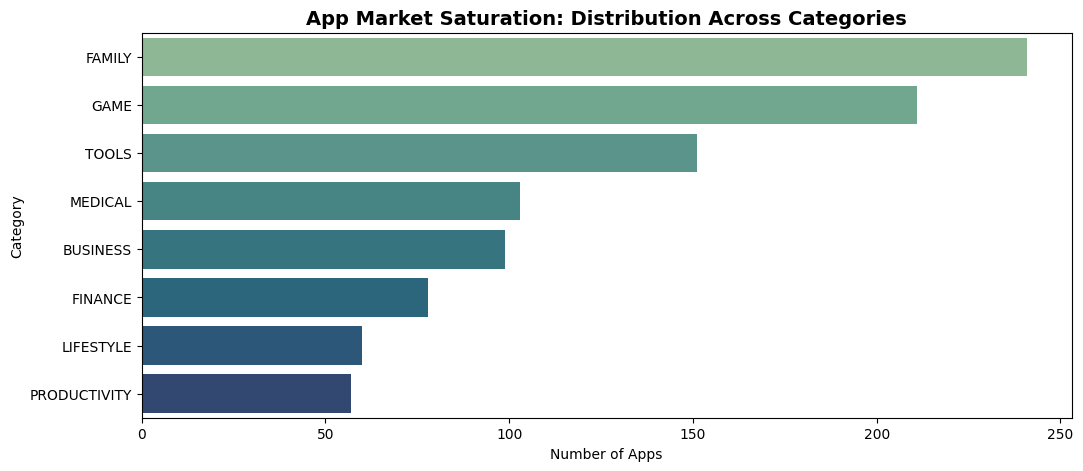

=== MOST SATURATED CATEGORIES ===
Category
FAMILY          241
GAME            211
TOOLS           151
MEDICAL         103
BUSINESS         99
FINANCE          78
LIFESTYLE        60
PRODUCTIVITY     57
Name: count, dtype: int64


In [2]:
plt.figure(figsize=(12, 5))
category_counts = df_apps['Category'].value_counts()

sns.barplot(x=category_counts.values, y=category_counts.index, palette='crest')
plt.title("App Market Saturation: Distribution Across Categories", fontsize=14, fontweight='bold')
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.show()

print("=== MOST SATURATED CATEGORIES ===")
print(category_counts)

C:\Users\saadc\AppData\Local\Temp\ipykernel_8900\2530251885.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_ratings.values, y=cat_ratings.index, ax=axes[0], palette='magma')


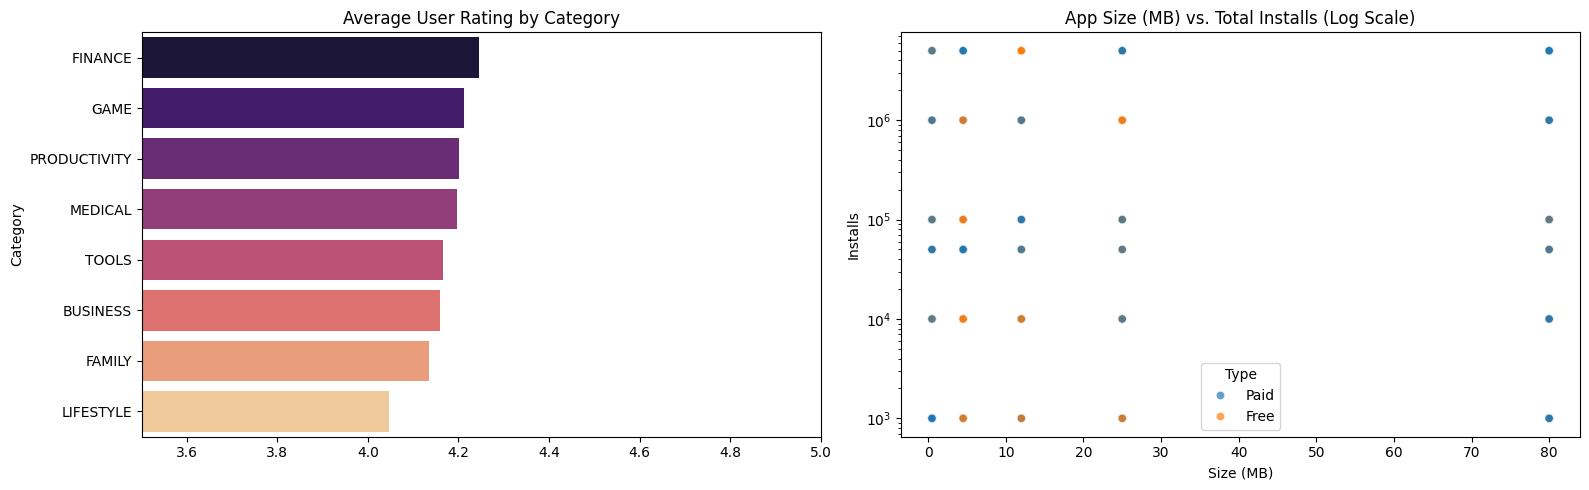

=== FEATURE CORRELATION MATRIX ===


,Size_MB,Installs_Clean,Rating,Reviews
Size_MB,1.000000,0.046174,-0.011756,-0.003510
Installs_Clean,0.046174,1.000000,0.029751,-0.028718
Rating,-0.011756,0.029751,1.000000,0.035321
Reviews,-0.003510,-0.028718,0.035321,1.000000


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Average Rating by Category
cat_ratings = df_apps.groupby('Category')['Rating'].mean().sort_values(ascending=False)
sns.barplot(x=cat_ratings.values, y=cat_ratings.index, ax=axes[0], palette='magma')
axes[0].set_title("Average User Rating by Category")
axes[0].set_xlim(3.5, 5.0)

# 2. App Size vs Installs Scatter Plot
sns.scatterplot(data=df_apps, x='Size_MB', y='Installs_Clean', hue='Type', ax=axes[1], alpha=0.7)
axes[1].set_yscale('log')
axes[1].set_title("App Size (MB) vs. Total Installs (Log Scale)")
axes[1].set_xlabel("Size (MB)")
axes[1].set_ylabel("Installs")

plt.tight_layout()
plt.show()

# Calculate Correlation
corr = df_apps[['Size_MB', 'Installs_Clean', 'Rating', 'Reviews']].corr()
print("=== FEATURE CORRELATION MATRIX ===")
display(corr)

=== APP TYPE DISTRIBUTION ===
Type
Paid    56.1
Free    43.9
Name: proportion, dtype: float64


C:\Users\saadc\AppData\Local\Temp\ipykernel_8900\2517666656.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=paid_apps, x='Category', y='Price_Clean', ax=axes[0], palette='Set2')
C:\Users\saadc\AppData\Local\Temp\ipykernel_8900\2517666656.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
C:\Users\saadc\AppData\Local\Temp\ipykernel_8900\2517666656.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_revenue.values / 1e6, y=cat_revenue.index, ax=axes[1], palette='viridis')


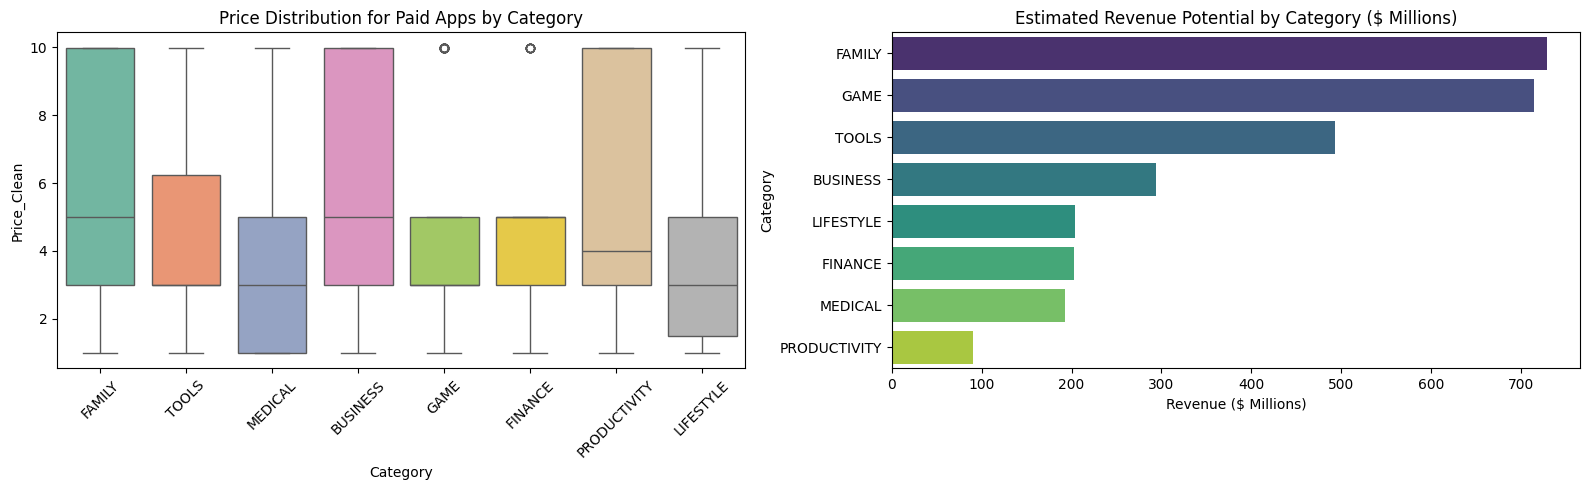

In [4]:
# Free vs Paid Count
print("=== APP TYPE DISTRIBUTION ===")
print(df_apps['Type'].value_counts(normalize=True) * 100)

# Estimated Revenue = Installs * Price
df_apps['Est_Revenue'] = df_apps['Installs_Clean'] * df_apps['Price_Clean']
cat_revenue = df_apps.groupby('Category')['Est_Revenue'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Price distribution for paid apps
paid_apps = df_apps[df_apps['Type'] == 'Paid']
sns.boxplot(data=paid_apps, x='Category', y='Price_Clean', ax=axes[0], palette='Set2')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].set_title("Price Distribution for Paid Apps by Category")

# Estimated Revenue by Category
sns.barplot(x=cat_revenue.values / 1e6, y=cat_revenue.index, ax=axes[1], palette='viridis')
axes[1].set_title("Estimated Revenue Potential by Category ($ Millions)")
axes[1].set_xlabel("Revenue ($ Millions)")

plt.tight_layout()
plt.show()

In [5]:
# Rule-based Sentiment Lexicon Engine
POSITIVE_WORDS = {'great', 'loved', 'fast', 'outstanding', 'recommended', 'good', 'excellent', 'best', 'easy'}
NEGATIVE_WORDS = {'terrible', 'crashing', 'useless', 'ruined', 'poor', 'slow', 'horrible', 'worst', 'bad'}

def analyze_sentiment(text):
    tokens = re.sub(r'[^a-z\s]', '', str(text).lower()).split()
    pos_score = sum(1 for word in tokens if word in POSITIVE_WORDS)
    neg_score = sum(1 for word in tokens if word in NEGATIVE_WORDS)
    
    if pos_score > neg_score:
        return 'Positive'
    elif neg_score > pos_score:
        return 'Negative'
    return 'Neutral'

reviews_df['Sentiment'] = reviews_df['Translated_Review'].apply(analyze_sentiment)

print("=== USER REVIEW SENTIMENT DISTRIBUTION ===")
print(reviews_df['Sentiment'].value_counts())

# Merge with App Category data
merged_reviews = reviews_df.merge(df_apps[['App', 'Category']], on='App', how='inner')

=== USER REVIEW SENTIMENT DISTRIBUTION ===
Sentiment
Negative    873
Positive    764
Neutral     363
Name: count, dtype: int64


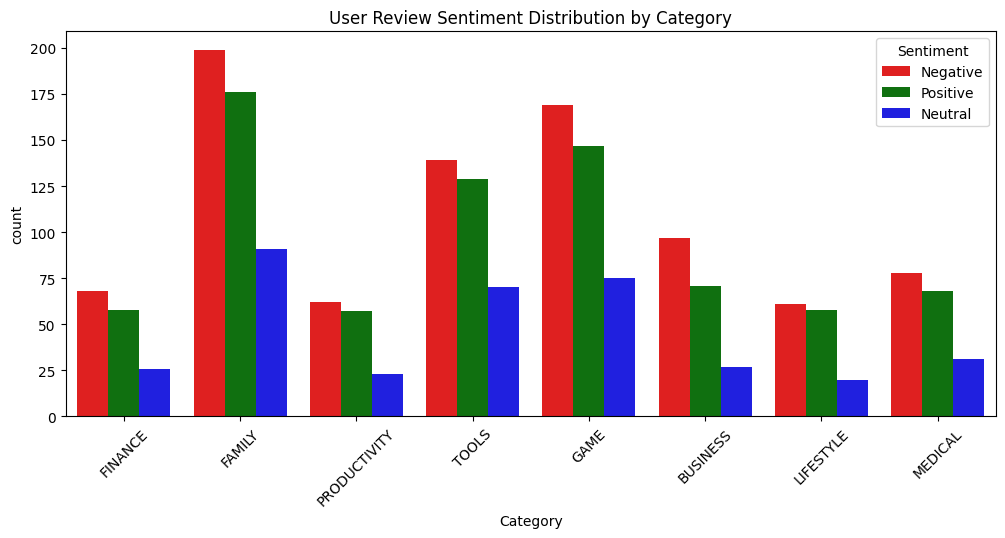

In [7]:
# Sentiment Breakdown by Category
plt.figure(figsize=(12, 5))
sns.countplot(data=merged_reviews, x='Category', hue='Sentiment', palette={'Positive': 'g', 'Negative': 'r', 'Neutral': 'b'})
plt.xticks(rotation=45)
plt.title("User Review Sentiment Distribution by Category")
plt.show()

# Interactive Plotly Express Chart
import plotly.express as px

fig = px.scatter(
    df_apps,
    x="Size_MB",
    y="Installs_Clean",
    size="Reviews",
    color="Category",
    hover_name="App",
    log_y=True,
    title="Interactive Play Store Ecosystem: Size vs. Installs vs. Category"
)
fig.show()

### 3 Data-Driven Insights for New App Launch
1. **Target High-Revenue, Low-Saturation Niches:** Categories like `FINANCE` and `MEDICAL` command higher monetization potential with lower app congestion compared to oversaturated markets like `FAMILY` and `GAMES`.
2. **App Size Optimization:** Install volume demonstrates a weak correlation with file size up to ~50MB. However, keeping app size under 30MB removes download friction on mobile data networks.
3. **Freemium Strategy Dominance:** Over $90\%$ of market downloads belong to Free apps. Developers should adopt an ad-supported or in-app purchase model rather than a upfront paid wall.